# DETECTION D'ANOMALIES SUR DES CAPTEURS 
Un test d'usure a été pratiqué sur 4 pièces qui étaient montées ensemble, à la fin du test la pièce 1 a eu une défaillance.
Les données sont enregistrées par des capteurs toutes les 10 minutes et représentent des vibrations sur les 4 pièces (données NASA)

In [2]:
# d'apres https://arun-thomas.xyz/2019-06-18-BearingAnalytics/

# library
import os
import pandas as pd
import numpy as np
from sklearn import preprocessing
import seaborn as sns
# sns.set(color_codes=True)

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import os
repertoire = "C:\\Users\\damgarro\\OneDrive - Publicis Groupe\\Documents\\Formations\\SCU Python\\NEW\\Python-ML\\data"
os.chdir(repertoire)


### Les données
Dégradation de la pièce (Gear) peut arriver progressivement au cours du temps, aussi le capteur enr. la donnée toutes les 10'
Il s'agit donc de séries temporelles

In [3]:
merged_data = pd.read_csv("sensorData\\merged_dataset_BearingTest_2.csv")

merged_data.columns = ['dt','Bearing 1','Bearing 2','Bearing 3','Bearing 4']
merged_data=merged_data.set_index('dt')

In [4]:
merged_data.head()

,Bearing 1,Bearing 2,Bearing 3,Bearing 4
dt,,,,
2004-02-12 10:32:39,0.058333,0.071832,0.083242,0.043067
2004-02-12 10:42:39,0.058995,0.074006,0.084435,0.044541
2004-02-12 10:52:39,0.060236,0.074227,0.083926,0.044443
2004-02-12 11:02:39,0.061455,0.073844,0.084457,0.045081
2004-02-12 11:12:39,0.061361,0.075609,0.082837,0.045118


In [40]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 984 entries, 2004-02-12 10:32:39 to 2004-02-19 06:22:39
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Bearing 1  984 non-null    float64
 1   Bearing 2  984 non-null    float64
 2   Bearing 3  984 non-null    float64
 3   Bearing 4  984 non-null    float64
dtypes: float64(4)
memory usage: 38.4+ KB


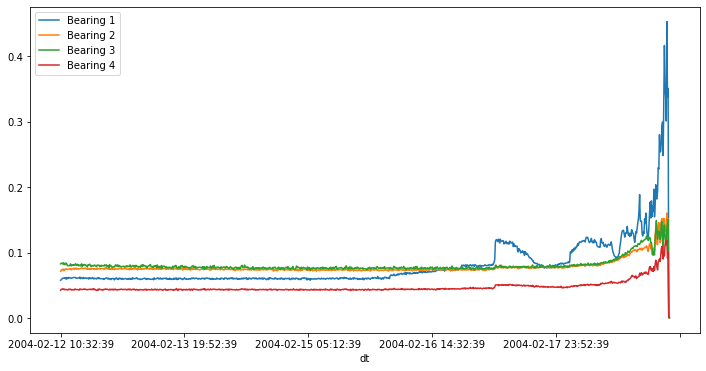

In [41]:
merged_data.plot(figsize = (12,6))


### COnstat : la courbe du capteur 1 suit une dérive forte 

<Axes: xlabel='dt'>

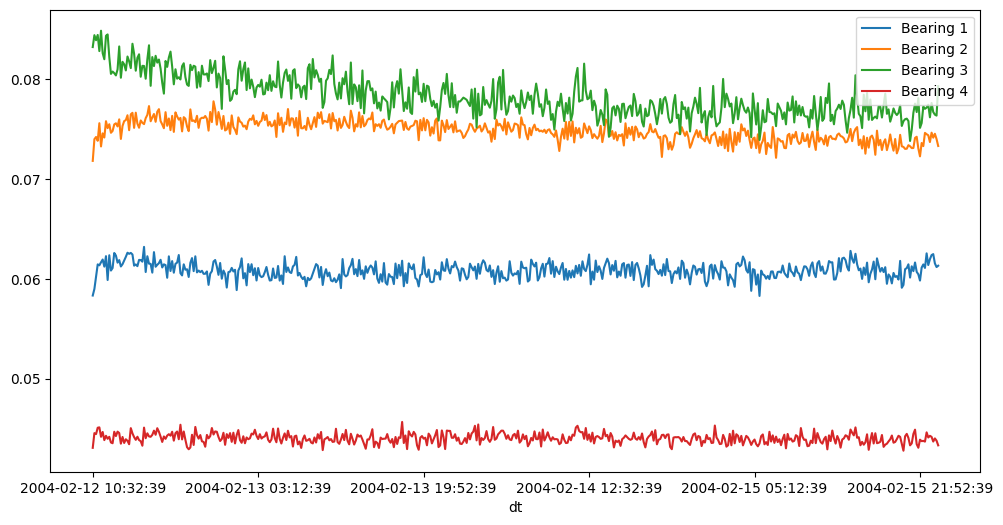

In [5]:
# sur les premiers jours, les 4 capteurs sont stables
merged_data['2004-02-12 10:32:39':'2004-02-15 23:42:39'].plot(figsize = (12,6))

### Prévision avec Prophet et détection d'anomalie sur le capteur 1
Prophet est un modèle de série temporelle qui a la particularité de nécessiter peu de paramétrage par l'utilisateur, le modèle est dit non paramétrique il s'adapte aux données

In [20]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [ ]:
# On va apprendre un modele sur la série SAINE : capteur 1 entre le 12/02/2004  et le 15/02/2004 => c'est le comportement attendu
healthy_bearing1 = merged_data['2004-02-12 10:32:39':'2004-02-15 23:42:39']['Bearing 1']

# Creating training dataframe
prophet_healthy_train = pd.DataFrame()
prophet_healthy_train['ds'] = healthy_bearing1.index
prophet_healthy_train['y'] = healthy_bearing1.values

prophet_healthy_train.head()

,ds,y
0,2004-02-12 10:32:39,0.058333
1,2004-02-12 10:42:39,0.058995
2,2004-02-12 10:52:39,0.060236
3,2004-02-12 11:02:39,0.061455
4,2004-02-12 11:12:39,0.061361


In [22]:
prophet_healthy_train.shape

(512, 2)

In [ ]:
# On apprend un modele sans les options de saisonnalité car il n'y en a pas dans les données (données de capteur)
# La bande de confiance est fixée au max 100% qui dit que toutes les données en conditions normales doivent etre dedans
# on peut la baisser un peu mais cela risque de créer bcp de faux positifs
m = Prophet(interval_width = 1)
# avec les données saines
m.fit(prophet_healthy_train)

13:10:37 - cmdstanpy - INFO - Chain [1] start processing
13:10:39 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
# faire des prévisions sur les données saines : cela permet de comparer les valeurs prédites avec les valeurs réelles
forecast = m.predict(prophet_healthy_train)
forecast['fact'] = prophet_healthy_train['y'].reset_index(drop = True)

In [25]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat,fact
0,2004-02-12 10:32:39,0.061311,0.058679,0.063460,0.061311,0.061311,-0.000176,-0.000176,-0.000176,-0.000176,-0.000176,-0.000176,0.0,0.0,0.0,0.061135,0.058333
1,2004-02-12 10:42:39,0.061312,0.058896,0.063158,0.061312,0.061312,-0.000164,-0.000164,-0.000164,-0.000164,-0.000164,-0.000164,0.0,0.0,0.0,0.061147,0.058995
2,2004-02-12 10:52:39,0.061312,0.058954,0.063174,0.061312,0.061312,-0.000148,-0.000148,-0.000148,-0.000148,-0.000148,-0.000148,0.0,0.0,0.0,0.061165,0.060236
3,2004-02-12 11:02:39,0.061313,0.058932,0.063410,0.061313,0.061313,-0.000126,-0.000126,-0.000126,-0.000126,-0.000126,-0.000126,0.0,0.0,0.0,0.061186,0.061455
4,2004-02-12 11:12:39,0.061314,0.058868,0.063591,0.061314,0.061314,-0.000101,-0.000101,-0.000101,-0.000101,-0.000101,-0.000101,0.0,0.0,0.0,0.061213,0.061361


In [26]:
forecast.shape

(512, 17)

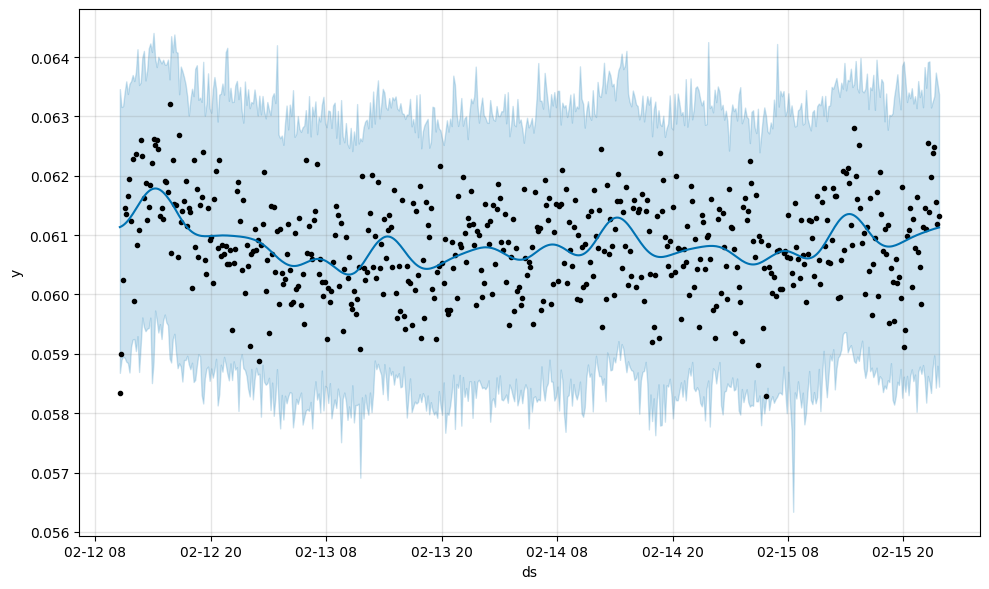

In [27]:
fig1 = m.plot(forecast)


[Text(0.5, 0, "observation au  pas 10'"),
 Text(0, 0.5, 'Vibration/Acceleration(g)')]

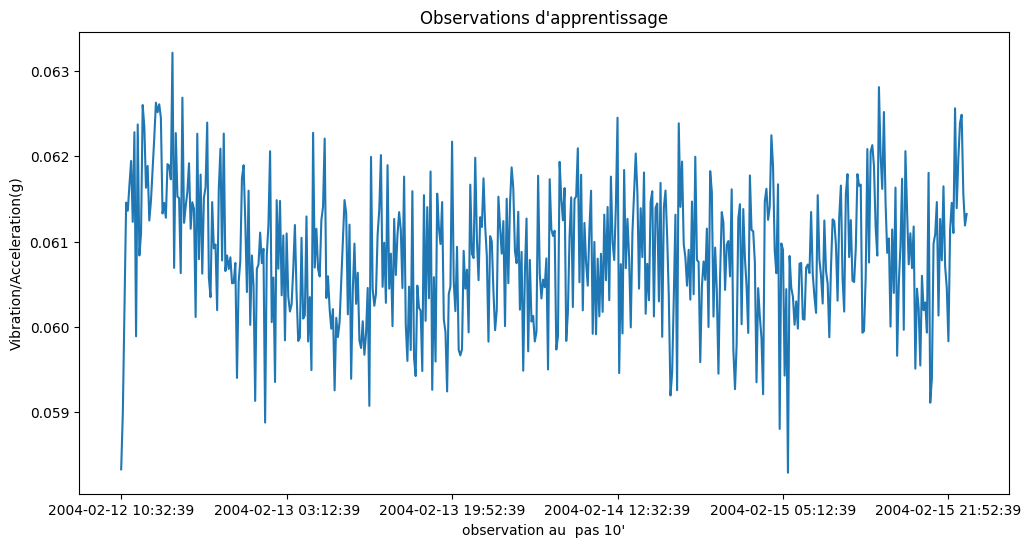

In [71]:
fig1 = healthy_bearing1.plot(figsize = (12,6), title="Observations d'apprentissage")
fig1.set(xlabel="observation au  pas 10'", ylabel="Vibration/Acceleration(g)")

In [29]:
forecast=forecast.set_index('ds')

### PARTIE 2 APPLICATION DU MODELE SUR DONNEES NOUVELLES POUR DETECTER DES EVENTUELLES ANOMALIES

In [ ]:
# données de test avec anomalies
prophet_faultydata = merged_data['2004-02-15 23:22:39':'2004-02-16 23:52:39']['Bearing 1']
prophet_faultydata.head()

dt
2004-02-15 23:22:39    0.061558
2004-02-15 23:32:39    0.061188
2004-02-15 23:42:39    0.061323
2004-02-15 23:52:39    0.064163
2004-02-16 00:02:39    0.060751
Name: Bearing 1, dtype: float64

[Text(0.5, 0, "observation au  pas 10'"),
 Text(0, 0.5, 'Vibration/Acceleration(g)')]

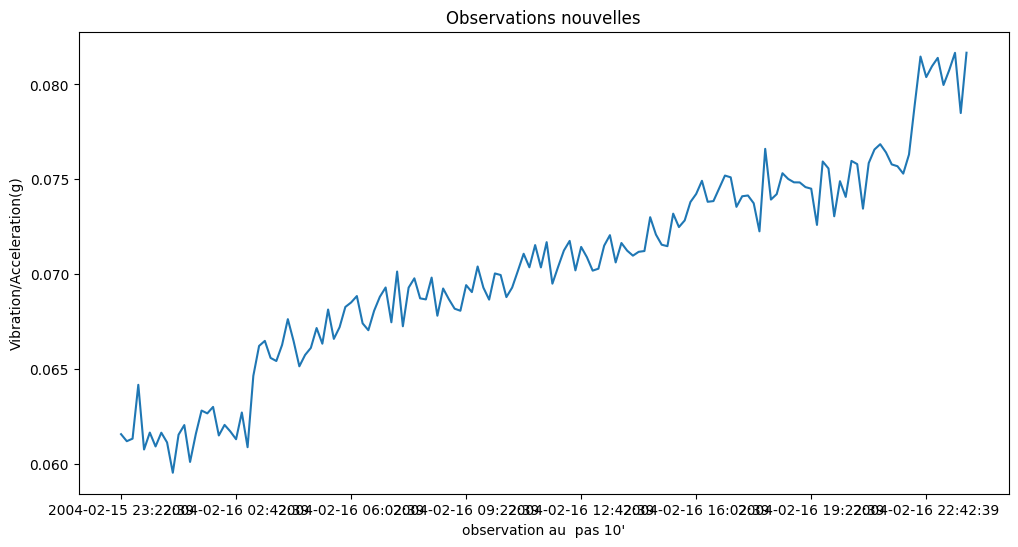

In [70]:
fig1 = prophet_faultydata.plot(figsize = (12,6), title="Observations nouvelles")
fig1.set(xlabel="observation au  pas 10'", ylabel="Vibration/Acceleration(g)")

In [31]:
prophet_faulty_test = pd.DataFrame()
prophet_faulty_test['ds'] = prophet_faultydata.index
#pd.to_datetime(prophet_healthy.index, format='%Y.%m.%d.%H.%M.%S')
prophet_faulty_test['y'] = prophet_faultydata.values
prophet_faulty_test.head()

,ds,y
0,2004-02-15 23:22:39,0.061558
1,2004-02-15 23:32:39,0.061188
2,2004-02-15 23:42:39,0.061323
3,2004-02-15 23:52:39,0.064163
4,2004-02-16 00:02:39,0.060751


In [74]:
forecast_test = m.predict(prophet_faulty_test)
forecast_test['fact_test'] = prophet_faulty_test['y'].reset_index(drop = True)

In [33]:
forecast_test.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat,fact_test
143,2004-02-16 23:12:39,0.061560,0.059041,0.064338,0.059773,0.062849,0.000042,0.000042,0.000042,0.000042,0.000042,0.000042,0.0,0.0,0.0,0.061602,0.079973
144,2004-02-16 23:22:39,0.061564,0.059085,0.064529,0.059756,0.062867,0.000047,0.000047,0.000047,0.000047,0.000047,0.000047,0.0,0.0,0.0,0.061610,0.080762
145,2004-02-16 23:32:39,0.061567,0.059116,0.064054,0.059739,0.062885,0.000051,0.000051,0.000051,0.000051,0.000051,0.000051,0.0,0.0,0.0,0.061618,0.081670
146,2004-02-16 23:42:39,0.061571,0.059142,0.064569,0.059723,0.062903,0.000054,0.000054,0.000054,0.000054,0.000054,0.000054,0.0,0.0,0.0,0.061625,0.078493
147,2004-02-16 23:52:39,0.061574,0.058762,0.064279,0.059706,0.062921,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.0,0.0,0.0,0.061631,0.081674


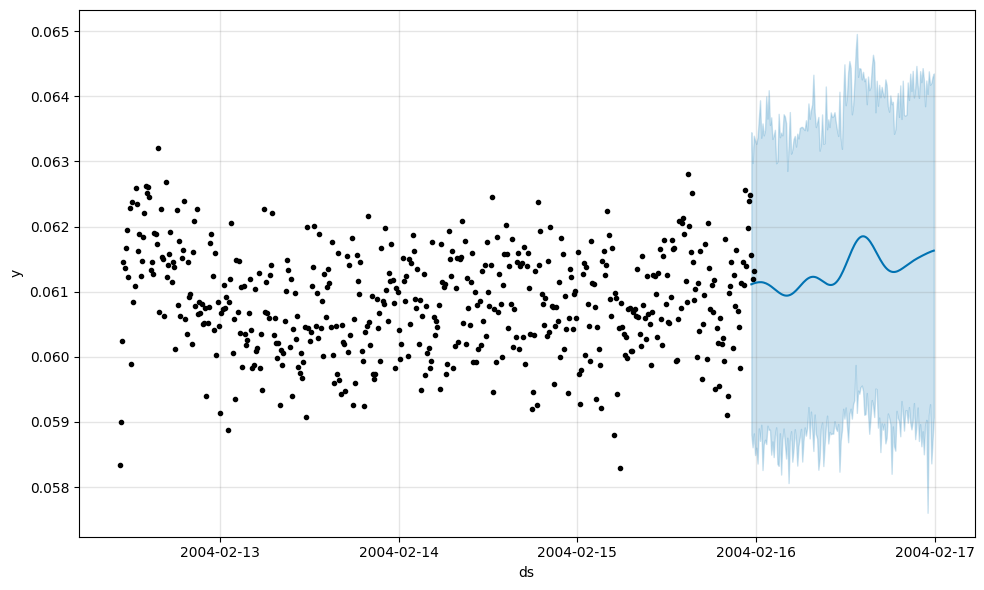

In [75]:
fig1 = m.plot(forecast_test)


In [36]:
forecast_test=forecast_test.set_index('ds')
prophet_healthy_train=prophet_healthy_train.set_index('ds')

In [37]:
# Apprentissage + Test

previsions=pd.concat([prophet_healthy_train,forecast_test])
previsions.head()

,y,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat,fact_test
ds,,,,,,,,,,,,,,,,,
2004-02-12 10:32:39,0.058333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-02-12 10:42:39,0.058995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-02-12 10:52:39,0.060236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-02-12 11:02:39,0.061455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-02-12 11:12:39,0.061361,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
previsions.head()
previsions['y'].mean()

np.float64(0.060839792058328)

In [39]:
previsions=previsions.reset_index()

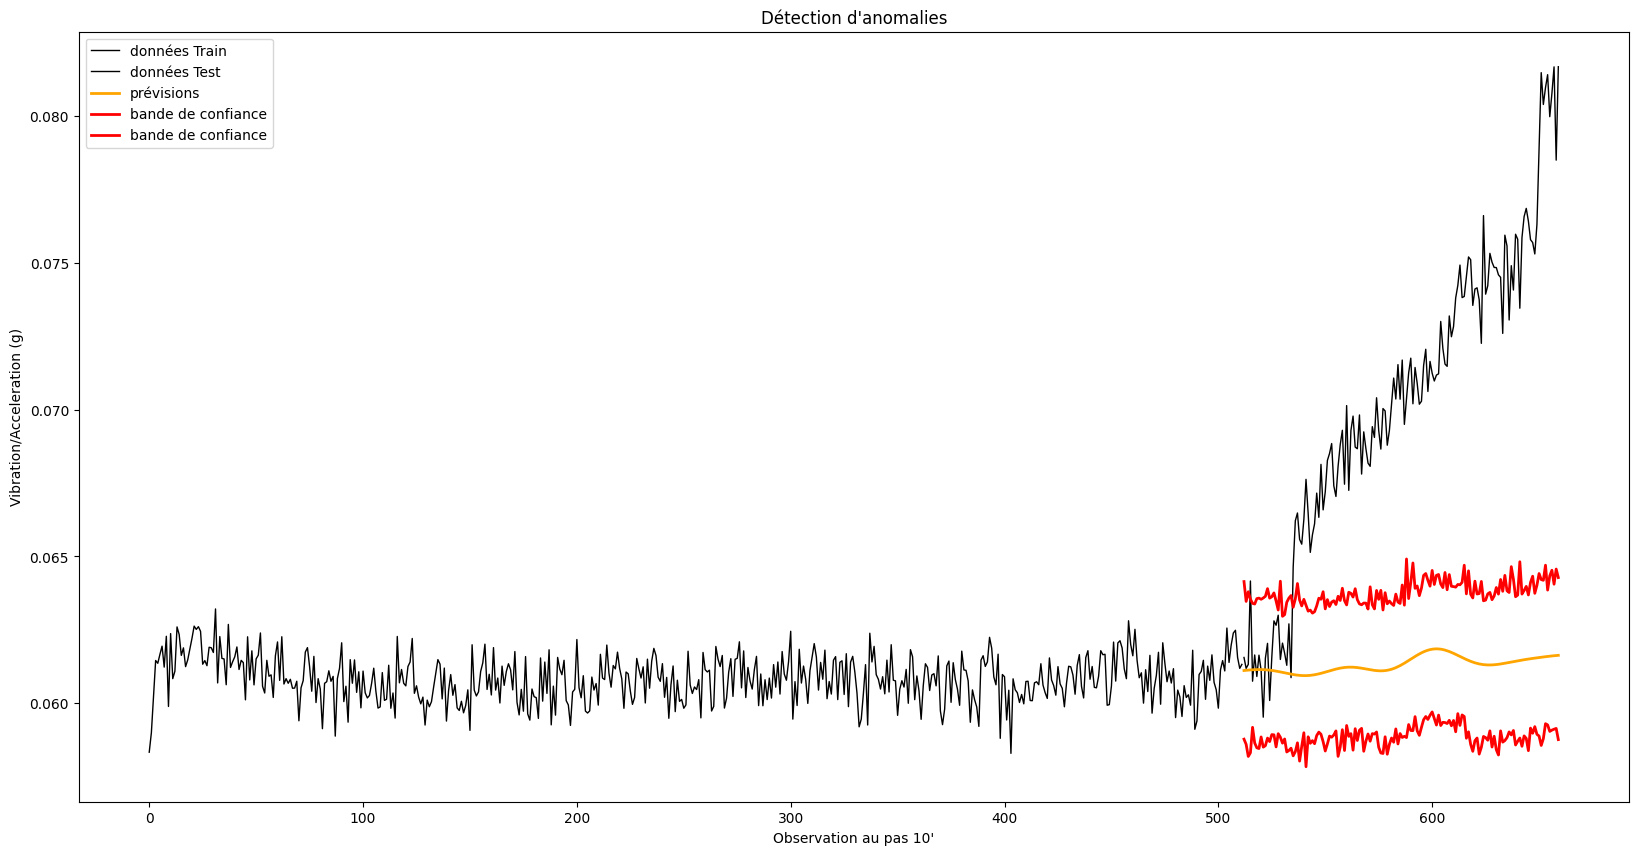

In [76]:
fig,ax=plt.subplots(figsize=(20, 10))
plt.plot(previsions['y'], color='black',lw=1, label = 'données Train')
plt.plot(previsions['fact_test'], color='black',lw=1, label = 'données Test')
plt.plot(previsions['yhat'], color='orange',lw=2, label = 'prévisions')
plt.plot(previsions['yhat_lower'], color='red',lw=2, label = 'bande de confiance')
plt.plot(previsions['yhat_upper'], color='red',lw=2, label = 'bande de confiance')
plt.xlabel("Observation au pas 10'"); plt.ylabel('Vibration/Acceleration (g)'); plt.title("Détection d'anomalies")
plt.legend()
#plt.savefig('graph.jpg')

### Codons un détecteur d'anomalies qui déclenche une anomalie lorsqu'on sort de la bande de confiance
anomaly = 0/1 et importance qui vaut l'écart entre la réalité et la bande

In [62]:
def detect_anomalies(forecast):
    forecasted = forecast[['ds','trend', 'yhat', 'yhat_lower', 'yhat_upper', 'fact_test']].copy()
    forecasted.columns = ['ds','trend', 'yhat', 'yhat_lower', 'yhat_upper', 'fact']

    forecasted['anomaly'] = 0
    forecasted.loc[forecasted['fact'] > forecasted['yhat_upper'], 'anomaly'] = 1
    forecasted.loc[forecasted['fact'] < forecasted['yhat_lower'], 'anomaly'] = -1

    #anomaly importances
    forecasted['importance'] = 0
    forecasted.loc[forecasted['anomaly'] ==1, 'importance'] = \
        (forecasted['fact'] - forecasted['yhat_upper'])/forecast['fact_test']
    forecasted.loc[forecasted['anomaly'] ==-1, 'importance'] = \
        (forecasted['yhat_lower'] - forecasted['fact'])/forecast['fact_test']
    
    return forecasted



In [63]:
pred = detect_anomalies(previsions)

In [64]:
pred.tail(10)

,ds,trend,yhat,yhat_lower,yhat_upper,fact,anomaly,importance
650,2004-02-16 22:22:39,0.061543,0.061556,0.058883,0.064416,0.078938,1,0.183958
651,2004-02-16 22:32:39,0.061547,0.061566,0.058563,0.064211,0.081473,1,0.211871
652,2004-02-16 22:42:39,0.061550,0.061575,0.058794,0.064186,0.080389,1,0.201554
653,2004-02-16 22:52:39,0.061554,0.061585,0.059303,0.064700,0.080961,1,0.200845
654,2004-02-16 23:02:39,0.061557,0.061594,0.059262,0.063853,0.081403,1,0.215596
655,2004-02-16 23:12:39,0.061560,0.061602,0.059041,0.064338,0.079973,1,0.195507
656,2004-02-16 23:22:39,0.061564,0.061610,0.059085,0.064529,0.080762,1,0.200996
657,2004-02-16 23:32:39,0.061567,0.061618,0.059116,0.064054,0.081670,1,0.215700
658,2004-02-16 23:42:39,0.061571,0.061625,0.059142,0.064569,0.078493,1,0.177392
659,2004-02-16 23:52:39,0.061574,0.061631,0.058762,0.064279,0.081674,1,0.212980


In [65]:
print(pred.anomaly.sum())
print(pred[pred.anomaly==1].head())

126
                      ds     trend      yhat  yhat_lower  yhat_upper  \
515  2004-02-15 23:52:39  0.061078  0.061135    0.058314    0.063547   
535  2004-02-16 03:12:39  0.061147  0.060977    0.058208    0.063269   
536  2004-02-16 03:22:39  0.061150  0.060965    0.058350    0.063552   
537  2004-02-16 03:32:39  0.061154  0.060956    0.058652    0.064077   
538  2004-02-16 03:42:39  0.061157  0.060948    0.058030    0.063514   

         fact  anomaly  importance  
515  0.064163        1    0.009600  
535  0.064636        1    0.021149  
536  0.066212        1    0.040175  
537  0.066479        1    0.036128  
538  0.065580        1    0.031513  


In [ ]:
# Si on constate plusieurs anomalies successives alors on alerte